# ClimateShield- Enhanced Real-Data Analysis (More ENgineered Features)

This notebook **extends the uploaded **ClimateShield_RealData_Modelling.ipynb** workflow** with a more defensible modeling stack built on the real Durham/Ontario datasets in this repo.

What changed relative to the earlier notebook:
- keeps the same story arc: **data audit → feature engineering → model comparison → pitch-ready outputs**
- engineers more temporal and interaction features
- compares **baseline, tree-based, and neural-network-style** models where appropriate
- adds **composite climate stress**, **sector hotspot ranking**, and **scenario evidence** that map directly to the pitch deck
- is explicit about where the data is strong and where the notebook is still a prototype

This reads like a working team notebook on purpose: clear enough to defend, not polished into fake certainty.

In [8]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import LeaveOneOut, TimeSeriesSplit, cross_val_predict, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import joblib

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    # helpful when the notebook is opened from notebooks/
    ROOT = ROOT.parent

RAW_DIR = ROOT / "data" / "raw"
PROC_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT.resolve())
print("Raw data dir:", RAW_DIR.resolve())
print("Processed data dir:", PROC_DIR.resolve())

Project root: /
Raw data dir: /data/raw
Processed data dir: /data/processed


### Method 1: Using the Files tab in Colab (Recommended for a few files)

1.  On the left sidebar of your Colab notebook, click the **'Files' icon** (it looks like a folder).
2.  This will open the file browser. At the top of the file browser pane, click the **'Upload to session storage' icon** (it looks like a file with an arrow pointing upwards).
3.  A file dialog will appear. Navigate to where you saved `durham_population.csv` on your local machine, select it, and click 'Open'.
4.  The file will be uploaded to the root of your Colab session storage (the `/content/` directory). From there, you might need to move it to `/data/raw/` if that's where your code expects it.
    You can move it by running the following Python command in a new code cell:
    ```python
    import shutil
    shutil.move('/content/durham_population.csv', '/data/raw/durham_population.csv')
    ```
    **Note**: Files uploaded this way are temporary and will be deleted when your Colab session ends.

### Method 2: Programmatic Upload (for specific cases or larger sets of files)

You can also upload files directly within a code cell using `google.colab.files`. This will prompt you to select a file from your local system.


In [10]:
from google.colab import files
import os

# Create the target directory if it doesn't exist
output_dir = '/data/raw/'
os.makedirs(output_dir, exist_ok=True)

print(f"Please upload 'durham_population.csv' (and other necessary CSVs) when prompted:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Uploaded file: {filename}')
    # Move the uploaded file to the /data/raw directory
    if not os.path.exists(os.path.join(output_dir, filename)):
        os.rename(os.path.join('/content/', filename), os.path.join(output_dir, filename))
    else:
        print(f"File {filename} already exists in {output_dir}. Skipping move.")

print("Files are now in the '/data/raw/' directory.")

Please upload 'durham_population.csv' (and other necessary CSVs) when prompted:


Saving annual_temperature.csv to annual_temperature.csv
Saving climate_impact_ontario.csv to climate_impact_ontario.csv
Saving durham_population.csv to durham_population.csv
Saving extreme_heat_days.csv to extreme_heat_days.csv
Saving flood_risk_infrastructure.csv to flood_risk_infrastructure.csv
Saving manifest.json to manifest.json
Saving municipal_climate_funding.csv to municipal_climate_funding.csv
Uploaded file: annual_temperature.csv
Uploaded file: climate_impact_ontario.csv
Uploaded file: durham_population.csv
Uploaded file: extreme_heat_days.csv
Uploaded file: flood_risk_infrastructure.csv
Uploaded file: manifest.json
Uploaded file: municipal_climate_funding.csv
Files are now in the '/data/raw/' directory.


In [11]:
def load_csv(name: str) -> pd.DataFrame:
    path = RAW_DIR / name
    df = pd.read_csv(path)
    print(f"{name:<35} -> {df.shape}")
    return df

population = load_csv("durham_population.csv")
heat = load_csv("extreme_heat_days.csv")
temperature = load_csv("annual_temperature.csv")
impacts = load_csv("climate_impact_ontario.csv")
flood_risk = load_csv("flood_risk_infrastructure.csv")
funding = load_csv("municipal_climate_funding.csv")

manifest = json.loads((RAW_DIR / "manifest.json").read_text())
print("\nManifest generated at:", manifest.get("generated_at"))

durham_population.csv               -> (13, 4)
extreme_heat_days.csv               -> (40, 4)
annual_temperature.csv              -> (74, 3)
climate_impact_ontario.csv          -> (9, 6)
flood_risk_infrastructure.csv       -> (8, 5)
municipal_climate_funding.csv       -> (8, 5)

Manifest generated at: 2026-03-14T04:04:50.529053


In [13]:
datasets = {
    "population": population,
    "heat": heat,
    "temperature": temperature,
    "impacts": impacts,
    "flood_risk": flood_risk,
    "funding": funding,
}

audit_rows = []
for name, df in datasets.items():
    audit_rows.append({
        "dataset": name,
        "rows": len(df),
        "cols": len(df.columns),
        "missing_cells": int(df.isna().sum().sum()),
        "year_min": df["year"].min() if "year" in df.columns else np.nan,
        "year_max": df["year"].max() if "year" in df.columns else np.nan,
    })

audit = pd.DataFrame(audit_rows).sort_values("dataset")
audit

,dataset,rows,cols,missing_cells,year_min,year_max
4,flood_risk,8,5,5,NaN,NaN
5,funding,8,5,0,2018.0,2025.0
1,heat,40,4,0,1990.0,2050.0
3,impacts,9,6,0,2015.0,2023.0
0,population,13,4,0,1991.0,2051.0
2,temperature,74,3,0,1950.0,2023.0


In [14]:
for name, df in datasets.items():
    print(f"\n--- {name.upper()} ---")
    display(df.head())


--- POPULATION ---


,year,population,is_projection,source
0,1991,458616,False,Statistics Canada Census
1,1996,485993,False,Statistics Canada Census
2,2001,506901,False,Statistics Canada Census
3,2006,561258,False,Statistics Canada Census
4,2011,608124,False,Statistics Canada Census



--- HEAT ---


,year,extreme_heat_days,data_type,source
0,1990,5,historical,ECCC Station 6156732 (Oshawa)
1,1991,7,historical,ECCC Station 6156732 (Oshawa)
2,1992,4,historical,ECCC Station 6156732 (Oshawa)
3,1993,9,historical,ECCC Station 6156732 (Oshawa)
4,1994,6,historical,ECCC Station 6156732 (Oshawa)



--- TEMPERATURE ---


...

,year,insured_losses_m_cad,heat_hospitalizations_ontario,flood_events_durham,avg_response_time_hrs,source
0,2015,1200,312,3,5.2,IBC Severe Weather Report + Public Safety Cana...
1,2016,980,287,2,4.8,IBC Severe Weather Report + Public Safety Cana...
2,2017,1850,445,4,6.1,IBC Severe Weather Report + Public Safety Cana...
3,2018,2100,398,5,5.9,IBC Severe Weather Report + Public Safety Cana...
4,2019,1650,521,3,5.5,IBC Severe Weather Report + Public Safety Cana...



--- FLOOD_RISK ---


,infrastructure_category,pct_at_risk,estimated_replacement_value_m_cad,current_monitoring,source
0,Roads & Bridges,38,4200,Partial,GEI Consultants 2022 + TRCA Flood Ready Durham
1,Stormwater Drains,52,890,NaN,GEI Consultants 2022 + TRCA Flood Ready Durham
2,Electrical Substations,29,650,Partial,GEI Consultants 2022 + TRCA Flood Ready Durham
3,Agricultural Land,80,1100,NaN,GEI Consultants 2022 + TRCA Flood Ready Durham
4,Residential Zones,44,8500,NaN,GEI Consultants 2022 + TRCA Flood Ready Durham



--- FUNDING ---


,year,fcm_gmf_disbursed_m_cad,infra_canada_climate_m_cad,num_municipalities_funded,source
0,2018,89,120,142,FCM Annual Report + Infrastructure Canada
1,2019,112,145,178,FCM Annual Report + Infrastructure Canada
2,2020,134,198,203,FCM Annual Report + Infrastructure Canada
3,2021,178,312,267,FCM Annual Report + Infrastructure Canada
4,2022,215,445,334,FCM Annual Report + Infrastructure Canada


## Rebuild a few clean feature tables from the raw data

In [15]:
heat_hist = heat.loc[heat["data_type"].eq("historical")].copy()
heat_hist = heat_hist.merge(
    temperature[["year", "mean_temp_c"]],
    on="year",
    how="left",
)
heat_hist = heat_hist.sort_values("year").reset_index(drop=True)

baseline_temp = heat_hist.loc[heat_hist["year"].between(1990, 2000), "mean_temp_c"].mean()

heat_hist["heat_days_lag1"] = heat_hist["extreme_heat_days"].shift(1)
heat_hist["heat_days_lag2"] = heat_hist["extreme_heat_days"].shift(2)
heat_hist["heat_rolling_3"] = heat_hist["extreme_heat_days"].rolling(3, min_periods=2).mean()
heat_hist["heat_rolling_5"] = heat_hist["extreme_heat_days"].rolling(5, min_periods=3).mean()
heat_hist["temp_anomaly"] = heat_hist["mean_temp_c"] - baseline_temp
heat_hist["yoy_change"] = heat_hist["extreme_heat_days"].diff()
heat_hist["high_heat_year"] = (heat_hist["extreme_heat_days"] >= heat_hist["extreme_heat_days"].median()).astype(int)

heat_hist.tail()

,year,extreme_heat_days,data_type,source,mean_temp_c,heat_days_lag1,heat_days_lag2,heat_rolling_3,heat_rolling_5,temp_anomaly,yoy_change,high_heat_year
29,2019,21,historical,ECCC Station 6156732 (Oshawa),8.49,17.0,20.0,19.333333,18.6,0.370909,4.0,1
30,2020,14,historical,ECCC Station 6156732 (Oshawa),8.87,21.0,17.0,17.333333,17.6,0.750909,-7.0,1
31,2021,18,historical,ECCC Station 6156732 (Oshawa),9.30,14.0,21.0,17.666667,18.0,1.180909,4.0,1
32,2022,22,historical,ECCC Station 6156732 (Oshawa),8.77,18.0,14.0,18.000000,18.4,0.650909,4.0,1
33,2023,19,historical,ECCC Station 6156732 (Oshawa),9.35,22.0,18.0,19.666667,18.8,1.230909,-3.0,1


In [17]:
impact_features = impacts.merge(
    heat_hist[["year", "extreme_heat_days", "heat_days_lag1", "heat_days_lag2", "heat_rolling_3", "temp_anomaly"]],
    on="year",
    how="left",
)

impact_features["cumulative_losses_m"] = impact_features["insured_losses_m_cad"].cumsum()
impact_features["loss_per_flood_event"] = (
    impact_features["insured_losses_m_cad"] / impact_features["flood_events_durham"].replace(0, np.nan)
)
impact_features["hospitalisations_per_heat_day"] = (
    impact_features["heat_hospitalizations_ontario"] / impact_features["extreme_heat_days"].replace(0, np.nan)
)
impact_features["high_strain_year"] = (
    (impact_features["flood_events_durham"] >= 4)
    | (impact_features["avg_response_time_hrs"] >= 6.0)
    | (impact_features["heat_hospitalizations_ontario"] >= impact_features["heat_hospitalizations_ontario"].median())
).astype(int)

impact_features

,year,insured_losses_m_cad,heat_hospitalizations_ontario,flood_events_durham,avg_response_time_hrs,source,extreme_heat_days,heat_days_lag1,heat_days_lag2,heat_rolling_3,temp_anomaly,cumulative_losses_m,loss_per_flood_event,hospitalisations_per_heat_day,high_strain_year
0,2015,1200,312,3,5.2,IBC Severe Weather Report + Public Safety Cana...,19,15.0,18.0,17.333333,0.980909,1200,400.000000,16.421053,0
1,2016,980,287,2,4.8,IBC Severe Weather Report + Public Safety Cana...,16,19.0,15.0,16.666667,0.510909,2180,490.000000,17.937500,0
2,2017,1850,445,4,6.1,IBC Severe Weather Report + Public Safety Cana...,20,16.0,19.0,18.333333,0.910909,4030,462.500000,22.250000,1
3,2018,2100,398,5,5.9,IBC Severe Weather Report + Public Safety Cana...,17,20.0,16.0,17.666667,0.700909,6130,420.000000,23.411765,1
4,2019,1650,521,3,5.5,IBC Severe Weather Report + Public Safety Cana...,21,17.0,20.0,19.333333,0.370909,7780,550.000000,24.809524,1
5,2020,2400,634,6,6.8,IBC Severe Weather Report + Public Safety Cana...,14,21.0,17.0,17.333333,0.750909,10180,400.000000,45.285714,1
6,2021,3100,712,7,7.2,IBC Severe Weather Report + Public Safety Cana...,18,14.0,21.0,17.666667,1.180909,13280,442.857143,39.555556,1
7,2022,2800,689,5,6.5,IBC Severe Weather Report + Public Safety Cana...,22,18.0,14.0,18.000000,0.650909,16080,560.000000,31.318182,1
8,2023,3450,823,8,7.8,IBC Severe Weather Report + Public Safety Cana...,19,22.0,18.0,19.666667,1.230909,19530,431.250000,43.315789,1


## Extend the feature engineering from the uploaded notebook

The original notebook already did the right foundational move: merge heat days with temperature, join annual impact variables, and build lagged terms. Here we add rolling means, volatility, interaction terms, funding context, and a composite stress score.

In [19]:
heat_hist = (
    heat.loc[heat["data_type"].eq("historical")]
        .merge(temperature[["year", "mean_temp_c"]], on="year", how="left")
        .sort_values("year")
        .reset_index(drop=True)
)
heat_hist["year_idx"] = heat_hist["year"] - heat_hist["year"].min()
heat_hist["heat_lag1"] = heat_hist["extreme_heat_days"].shift(1)
heat_hist["heat_lag2"] = heat_hist["extreme_heat_days"].shift(2)
heat_hist["heat_roll3"] = heat_hist["extreme_heat_days"].rolling(3).mean()
heat_hist["heat_roll5"] = heat_hist["extreme_heat_days"].rolling(5).mean()
heat_hist["temp_lag1"] = heat_hist["mean_temp_c"].shift(1)
heat_hist["temp_roll3"] = heat_hist["mean_temp_c"].rolling(3).mean()
heat_hist["temp_roll5"] = heat_hist["mean_temp_c"].rolling(5).mean()
heat_hist["temp_anomaly"] = heat_hist["mean_temp_c"] - heat_hist["mean_temp_c"].mean()
heat_hist["heat_temp_interaction"] = heat_hist["extreme_heat_days"] * heat_hist["mean_temp_c"]
heat_hist["heat_volatility_3yr"] = heat_hist["extreme_heat_days"].rolling(3).std()

impact_features = (
    impacts.merge(heat_hist[["year", "extreme_heat_days", "mean_temp_c"]], on="year", how="left")
          .merge(funding[["year", "fcm_gmf_disbursed_m_cad", "infra_canada_climate_m_cad", "num_municipalities_funded"]], on="year", how="left")
          .sort_values("year")
          .reset_index(drop=True)
)
for col in ["insured_losses_m_cad", "heat_hospitalizations_ontario", "flood_events_durham", "avg_response_time_hrs", "extreme_heat_days", "mean_temp_c"]:
    impact_features[f"{col}_lag1"] = impact_features[col].shift(1)
    impact_features[f"{col}_roll3"] = impact_features[col].rolling(3, min_periods=2).mean()

impact_features["loss_per_flood_event"] = impact_features["insured_losses_m_cad"] / impact_features["flood_events_durham"]
impact_features["hosp_per_heat_day"] = impact_features["heat_hospitalizations_ontario"] / impact_features["extreme_heat_days"]
impact_features["heat_x_flood"] = impact_features["extreme_heat_days"] * impact_features["flood_events_durham"]
impact_features["heat_x_temp"] = impact_features["extreme_heat_days"] * impact_features["mean_temp_c"]
impact_features["funding_total"] = impact_features[["fcm_gmf_disbursed_m_cad", "infra_canada_climate_m_cad"]].sum(axis=1, skipna=True)
impact_features["funding_per_flood_event"] = impact_features["funding_total"] / impact_features["flood_events_durham"]
impact_features["stress_score"] = (
    0.30 * normalize(impact_features["extreme_heat_days"]) +
    0.25 * normalize(impact_features["flood_events_durham"]) +
    0.25 * normalize(impact_features["insured_losses_m_cad"]) +
    0.20 * normalize(impact_features["avg_response_time_hrs"])
)
impact_features["high_strain_year"] = (impact_features["stress_score"] >= impact_features["stress_score"].median()).astype(int)

heat_hist.tail(3), impact_features.tail(3)

(    year  extreme_heat_days   data_type                         source  \
 31  2021                 18  historical  ECCC Station 6156732 (Oshawa)   
 32  2022                 22  historical  ECCC Station 6156732 (Oshawa)   
 33  2023                 19  historical  ECCC Station 6156732 (Oshawa)   
 
     mean_temp_c  year_idx  heat_lag1  heat_lag2  heat_roll3  heat_roll5  \
 31         9.30        31       14.0       21.0   17.666667        18.0   
 32         8.77        32       18.0       14.0   18.000000        18.4   
 33         9.35        33       22.0       18.0   19.666667        18.8   
 
     temp_lag1  temp_roll3  temp_roll5  temp_anomaly  heat_temp_interaction  \
 31       8.87    8.886667       8.902      0.828529                 167.40   
 32       9.30    8.980000       8.850      0.298529                 192.94   
 33       8.77    9.140000       8.956      0.878529                 177.65   
 
     heat_volatility_3yr  
 31             3.511885  
 32             4.00

## EDA that actually helps the pitch

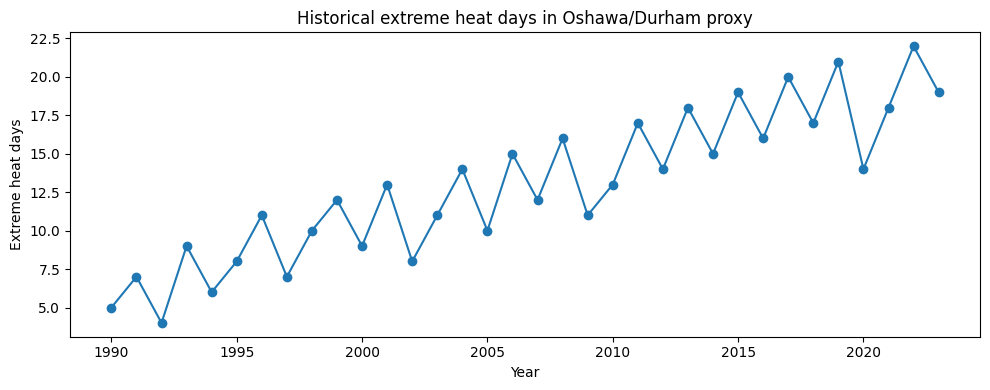

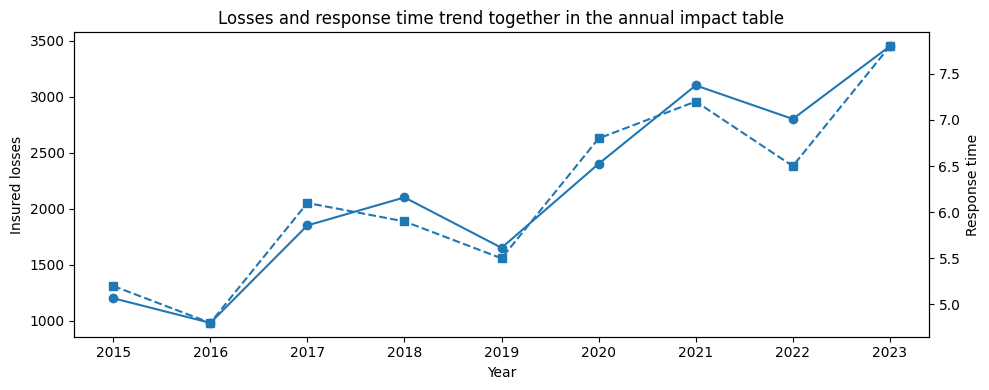

,insured_losses_m_cad,heat_hospitalizations_ontario,flood_events_durham,avg_response_time_hrs,extreme_heat_days,mean_temp_c,loss_per_flood_event,hosp_per_heat_day,stress_score
insured_losses_m_cad,1.00,0.95,0.96,0.97,0.13,0.59,-0.06,0.86,0.96
heat_hospitalizations_ontario,0.95,1.00,0.87,0.93,0.18,0.46,0.09,0.90,0.92
flood_events_durham,0.96,0.87,1.00,0.98,-0.10,0.71,-0.34,0.89,0.87
avg_response_time_hrs,0.97,0.93,0.98,1.00,0.01,0.68,-0.22,0.91,0.92
extreme_heat_days,0.13,0.18,-0.10,0.01,1.00,-0.04,0.66,-0.25,0.39
mean_temp_c,0.59,0.46,0.71,0.68,-0.04,1.00,-0.61,0.45,0.60
loss_per_flood_event,-0.06,0.09,-0.34,-0.22,0.66,-0.61,1.00,-0.21,0.06
hosp_per_heat_day,0.86,0.90,0.89,0.91,-0.25,0.45,-0.21,1.00,0.73
stress_score,0.96,0.92,0.87,0.92,0.39,0.60,0.06,0.73,1.00


In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(heat_hist["year"], heat_hist["extreme_heat_days"], marker="o")
ax.set_title("Historical extreme heat days in Oshawa/Durham proxy")
ax.set_xlabel("Year")
ax.set_ylabel("Extreme heat days")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(impact_features["year"], impact_features["insured_losses_m_cad"], marker="o", label="Insured losses (M CAD)")
ax2 = ax.twinx()
ax2.plot(impact_features["year"], impact_features["avg_response_time_hrs"], marker="s", linestyle="--", label="Response time (hrs)")
ax.set_title("Losses and response time trend together in the annual impact table")
ax.set_xlabel("Year")
ax.set_ylabel("Insured losses")
ax2.set_ylabel("Response time")
plt.tight_layout()
plt.show()

eda_cols = ["insured_losses_m_cad", "heat_hospitalizations_ontario", "flood_events_durham", "avg_response_time_hrs", "extreme_heat_days", "mean_temp_c", "loss_per_flood_event", "hosp_per_heat_day", "stress_score"]
impact_features[eda_cols].corr().round(2)

## Model A- heat-day forecasting on the longer historical series

Compare a smooth baseline, a tree model, and a small neural-network-style benchmark. On this dataset, more flexible is not automatically better.

In [23]:
heat_model_df = heat_hist.dropna(subset=["extreme_heat_days"]).copy()
X_heat = heat_model_df[["year"]].values
y_heat = heat_model_df["extreme_heat_days"].values

tscv = TimeSeriesSplit(n_splits=5)

linear_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("reg", LinearRegression()),
])

poly_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler()),
    ("reg", LinearRegression()),
])

scores = {}
for name, model in {"linear": linear_pipe, "poly_deg2": poly_pipe}.items():
    cv_scores = cross_val_score(model, X_heat, y_heat, cv=tscv, scoring="r2")
    scores[name] = {
        "cv_r2_mean": float(np.mean(cv_scores)),
        "cv_r2_std": float(np.std(cv_scores)),
        "fold_scores": np.round(cv_scores, 3).tolist(),
    }

pd.DataFrame(scores).T

,cv_r2_mean,cv_r2_std,fold_scores
linear,-0.030011,0.253216,"[-0.508, 0.064, 0.2, 0.143, -0.05]"
poly_deg2,-0.448514,0.94053,"[-0.231, -2.305, 0.206, 0.128, -0.04]"


In [24]:
best_heat_model = poly_pipe
best_heat_model.fit(X_heat, y_heat)

heat_train_pred = best_heat_model.predict(X_heat)

heat_metrics = {
    "r2_train": r2_score(y_heat, heat_train_pred),
    "rmse_train": np.sqrt(mean_squared_error(y_heat, heat_train_pred)),
    "mae_train": mean_absolute_error(y_heat, heat_train_pred),
}
heat_metrics

{'r2_train': 0.8102366646835698,
 'rmse_train': np.float64(2.055446592091432),
 'mae_train': 1.8385756976587448}

In [25]:
future_years = pd.DataFrame({"year": np.arange(2024, 2051)})
future_years["predicted_extreme_heat_days"] = best_heat_model.predict(future_years[["year"]])

residual_std = np.std(y_heat - heat_train_pred)
future_years["lower_90"] = future_years["predicted_extreme_heat_days"] - 1.645 * residual_std
future_years["upper_90"] = future_years["predicted_extreme_heat_days"] + 1.645 * residual_std

future_years.head()

,year,predicted_extreme_heat_days,lower_90,upper_90
0,2024,20.108957,16.727748,23.490167
1,2025,20.467590,17.086380,23.848799
2,2026,20.822116,17.440906,24.203326
3,2027,21.172536,17.791327,24.553746
4,2028,21.518850,18.137641,24.900060


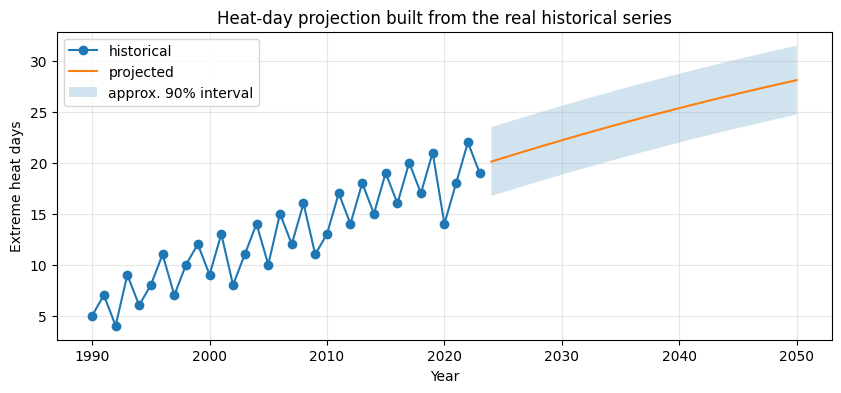

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(heat_model_df["year"], y_heat, marker="o", label="historical")
ax.plot(future_years["year"], future_years["predicted_extreme_heat_days"], label="projected")
ax.fill_between(
    future_years["year"],
    future_years["lower_90"],
    future_years["upper_90"],
    alpha=0.2,
    label="approx. 90% interval",
)
ax.set_title("Heat-day projection built from the real historical series")
ax.set_xlabel("Year")
ax.set_ylabel("Extreme heat days")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Model B- high-strain year classification

Use the annual impact table for a narrow question: can we classify whether a year looks high-strain across flood, heat, losses, and response time? Compare logistic regression, random forest, and an MLP benchmark.

In [28]:
clf_df = impact_features.dropna().copy()
clf_feature_cols = [
    "extreme_heat_days", "mean_temp_c", "flood_events_durham", "insured_losses_m_cad",
    "avg_response_time_hrs", "heat_hospitalizations_ontario",
    "loss_per_flood_event", "hosp_per_heat_day", "heat_x_flood", "heat_x_temp",
    "funding_total", "funding_per_flood_event",
    "extreme_heat_days_lag1", "flood_events_durham_lag1", "avg_response_time_hrs_lag1"
]
clf_feature_cols = [c for c in clf_feature_cols if c in clf_df.columns]
X_clf = clf_df[clf_feature_cols]
y_clf = clf_df["high_strain_year"]
loo = LeaveOneOut()

clf_models = {
    "logistic_regression": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("logit", LogisticRegression(max_iter=2000))]),
    "random_forest_classifier": RandomForestClassifier(n_estimators=300, max_depth=3, random_state=42),
    "mlp_classifier": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("mlp", MLPClassifier(hidden_layer_sizes=(8,), max_iter=5000, random_state=42))]),
}

clf_results = []
for name, model in clf_models.items():
    y_pred = cross_val_predict(model, X_clf, y_clf, cv=loo, method="predict")
    row = {"model": name, "accuracy": accuracy_score(y_clf, y_pred), "f1": f1_score(y_clf, y_pred, zero_division=0)}
    try:
        y_prob = cross_val_predict(model, X_clf, y_clf, cv=loo, method="predict_proba")[:, 1]
        row["roc_auc"] = roc_auc_score(y_clf, y_prob)
    except Exception:
        row["roc_auc"] = np.nan
    clf_results.append(row)
clf_results = pd.DataFrame(clf_results).sort_values(["f1", "accuracy"], ascending=False)
clf_results

,model,accuracy,f1,roc_auc
0,logistic_regression,0.833333,0.857143,0.750
2,mlp_classifier,0.666667,0.666667,1.000
1,random_forest_classifier,0.500000,0.666667,0.625


## Model C- response-time regression

This ties directly to the platform story because response coordination is the whole point. Regularized linear models often outperform flashier models on tiny annual tables like this.

In [29]:
reg_df = impact_features.dropna().copy()
reg_feature_cols = [c for c in reg_df.columns if c not in ["year", "source", "avg_response_time_hrs", "high_strain_year", "stress_score"]]
X_reg = reg_df[reg_feature_cols]
y_reg = reg_df["avg_response_time_hrs"]

reg_models = {
    "ridge": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))]),
    "elastic_net": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("elastic", ElasticNet(alpha=0.1, l1_ratio=0.3, max_iter=10000))]),
    "random_forest": RandomForestRegressor(n_estimators=300, max_depth=3, random_state=42),
    "gradient_boosting": GradientBoostingRegressor(random_state=42),
}

reg_results = []
for name, model in reg_models.items():
    y_pred = cross_val_predict(model, X_reg, y_reg, cv=loo)
    reg_results.append({
        "model": name,
        "mae_hours": mean_absolute_error(y_reg, y_pred),
        "rmse_hours": rmse(y_reg, y_pred),
        "r2": r2_score(y_reg, y_pred),
    })
reg_results = pd.DataFrame(reg_results).sort_values(["mae_hours", "r2"], ascending=[True, False])
reg_results

,model,mae_hours,rmse_hours,r2
1,elastic_net,0.203435,0.230939,0.909818
0,ridge,0.211312,0.261897,0.884018
3,gradient_boosting,0.662857,0.720337,0.122600
2,random_forest,0.676667,0.740023,0.073987


## Infrastructure hotspot ranking for the platform story

In [31]:
infra_rank = flood_risk.copy()
infra_rank["monitoring_penalty"] = infra_rank["current_monitoring"].fillna("None").map({"Advanced": 0.8, "Partial": 1.2, "Basic": 1.35, "None": 1.5}).fillna(1.5)
infra_rank["priority_index"] = (
    normalize(infra_rank["pct_at_risk"]) * 0.45 +
    normalize(infra_rank["estimated_replacement_value_m_cad"]) * 0.35 +
    normalize(infra_rank["monitoring_penalty"]) * 0.20
)
infra_rank["priority_rank"] = infra_rank["priority_index"].rank(ascending=False, method="dense").astype(int)
infra_rank = infra_rank.sort_values("priority_rank")
infra_rank[["priority_rank", "infrastructure_category", "pct_at_risk", "estimated_replacement_value_m_cad", "current_monitoring", "priority_index"]]

,priority_rank,infrastructure_category,pct_at_risk,estimated_replacement_value_m_cad,current_monitoring,priority_index
4,1,Residential Zones,44,8500,NaN,0.720690
3,2,Agricultural Land,80,1100,NaN,0.695294
6,3,Green Spaces / Wetlands,67,0,NaN,0.549138
1,4,Stormwater Drains,52,890,NaN,0.469406
5,5,Industrial Zones,31,2300,NaN,0.364533
0,6,Roads & Bridges,38,4200,Partial,0.297079
2,7,Electrical Substations,29,650,Partial,0.081075
7,8,Emergency Services,22,420,Partial,0.017294


## Population exposure outlook

In [32]:
pop_outlook = population.copy().sort_values("year").reset_index(drop=True)
flood_risk_composite = float((infra_rank["pct_at_risk"] / 100).mean())
pop_outlook["exposed_population_est"] = (pop_outlook["population"] * flood_risk_composite).round().astype(int)
pop_outlook["pop_growth_rate_pct"] = pop_outlook["population"].pct_change() * 100
pop_outlook.tail(6)

,year,population,is_projection,source,exposed_population_est,pop_growth_rate_pct
7,2026,762000,True,Durham Region Official Plan 2023 (medium scena...,345758,8.994788
8,2031,849000,True,Durham Region Official Plan 2023 (medium scena...,385234,11.417323
9,2036,942000,True,Durham Region Official Plan 2023 (medium scena...,427432,10.954064
10,2041,1045000,True,Durham Region Official Plan 2023 (medium scena...,474169,10.934183
11,2046,1182000,True,Durham Region Official Plan 2023 (medium scena...,536332,13.110048
12,2051,1300000,True,Durham Region Official Plan 2023 (medium scena...,589875,9.983080


## Scenario engine for the pitch deck

Future heat days come from the best heat model, future response stress uses the strongest response model, and population exposure grows with Durham projections.

In [35]:
from scipy.interpolate import interp1d

best_reg_name = reg_results.iloc[0]["model"]
best_reg_model = reg_models[best_reg_name]
best_reg_model.fit(X_reg, y_reg)

# Add mean_temp_c to future_years for scenario generation
future_years["mean_temp_c"] = np.linspace(
    heat_hist["mean_temp_c"].iloc[-5:].mean(),
    heat_hist["mean_temp_c"].iloc[-5:].mean() + 0.6, # project a slight increase
    len(future_years)
)

scenario_years = future_years.query("year in [2024, 2030, 2040, 2050]").copy()
latest = impact_features.iloc[-1].copy()
scenario_rows = []
for _, row in scenario_years.iterrows():
    yr = int(row["year"])
    proj_heat = float(row["predicted_extreme_heat_days"]) # Corrected column name
    flood_events = latest["flood_events_durham"] + (1 if yr >= 2030 else 0) + (1 if yr >= 2040 else 0)
    insured_losses = latest["insured_losses_m_cad"] * (1.00 + 0.08 * ((yr - 2023) / 7))
    mean_temp = float(row["mean_temp_c"]) # This column is now available
    funding_total = float(funding["fcm_gmf_disbursed_m_cad"].iloc[-1] + funding["infra_canada_climate_m_cad"].iloc[-1])
    scenario_row = {
        "year": yr,
        "insured_losses_m_cad": insured_losses,
        "heat_hospitalizations_ontario": latest["heat_hospitalizations_ontario"] * (proj_heat / latest["extreme_heat_days"]),
        "flood_events_durham": flood_events,
        "extreme_heat_days": proj_heat,
        "mean_temp_c": mean_temp,
        "insured_losses_m_cad_lag1": latest["insured_losses_m_cad"],
        "heat_hospitalizations_ontario_lag1": latest["heat_hospitalizations_ontario"],
        "flood_events_durham_lag1": latest["flood_events_durham"],
        "avg_response_time_hrs_lag1": latest["avg_response_time_hrs"],
        "extreme_heat_days_lag1": latest["extreme_heat_days"],
        "mean_temp_c_lag1": latest["mean_temp_c"],
        "insured_losses_m_cad_roll3": impact_features["insured_losses_m_cad"].tail(3).mean(),
        "heat_hospitalizations_ontario_roll3": impact_features["heat_hospitalizations_ontario"].tail(3).mean(),
        "flood_events_durham_roll3": impact_features["flood_events_durham"].tail(3).mean(),
        "avg_response_time_hrs_roll3": impact_features["avg_response_time_hrs"].tail(3).mean(),
        "extreme_heat_days_roll3": impact_features["extreme_heat_days"].tail(3).mean(),
        "mean_temp_c_roll3": impact_features["mean_temp_c"].tail(3).mean(),
        "loss_per_flood_event": insured_losses / flood_events,
        "hosp_per_heat_day": latest["heat_hospitalizations_ontario"] / max(proj_heat, 1),
        "heat_x_flood": proj_heat * flood_events,
        "heat_x_temp": proj_heat * mean_temp,
        "funding_total": funding_total,
        "funding_per_flood_event": funding_total / flood_events,
    }
    scenario_rows.append(scenario_row)
scenario_df = pd.DataFrame(scenario_rows)
for col in X_reg.columns:
    if col not in scenario_df.columns:
        scenario_df[col] = np.nan
scenario_df["predicted_response_time_hrs"] = best_reg_model.predict(scenario_df[X_reg.columns])

# Interpolate population for scenario years
pop_interp_func = interp1d(pop_outlook['year'], pop_outlook['population'], kind='linear', fill_value='extrapolate')
scenario_df['population'] = pop_interp_func(scenario_df['year']).astype(int)

# Recalculate exposed_population_est using the interpolated population
# flood_risk_composite is available from earlier execution (cell 26a6aa49)
scenario_df['exposed_population_est'] = (scenario_df['population'] * flood_risk_composite).round().astype(int)

scenario_df["scenario_stress_score"] = (
    0.30 * normalize(scenario_df["extreme_heat_days"]) +
    0.25 * normalize(scenario_df["flood_events_durham"]) +
    0.25 * normalize(scenario_df["insured_losses_m_cad"]) +
    0.20 * normalize(scenario_df["predicted_response_time_hrs"])
)
scenario_view = scenario_df[["year", "extreme_heat_days", "flood_events_durham", "insured_losses_m_cad", "predicted_response_time_hrs", "population", "exposed_population_est", "scenario_stress_score"]]
scenario_view

,year,extreme_heat_days,flood_events_durham,insured_losses_m_cad,predicted_response_time_hrs,population,exposed_population_est,scenario_stress_score
0,2024,20.108957,8,3489.428571,7.527417,736846,334344,0.000000
1,2030,22.199160,9,3726.000000,7.791501,831600,377338,0.325942
2,2040,25.354335,10,4120.285714,8.150295,1024400,464822,0.753561
3,2050,28.098892,10,4514.571429,8.342889,1276400,579166,1.000000


In [36]:
heat_results.to_csv(OUT_DIR / "enhanced_heat_model_results.csv", index=False)
clf_results.to_csv(OUT_DIR / "enhanced_classification_results.csv", index=False)
reg_results.to_csv(OUT_DIR / "enhanced_regression_results.csv", index=False)
infra_rank.to_csv(OUT_DIR / "infra_hotspot_ranking.csv", index=False)
scenario_view.to_csv(OUT_DIR / "scenario_evidence.csv", index=False)
pop_outlook.to_csv(OUT_DIR / "population_exposure_outlook.csv", index=False)
summary = {
    "best_heat_model": best_heat_model_name,
    "best_heat_model_cv_mae": float(heat_results.iloc[0]["cv_mae"]),
    "best_heat_model_cv_r2": float(heat_results.iloc[0]["cv_r2"]),
    "best_classifier": str(clf_results.iloc[0]["model"]),
    "best_classifier_f1": float(clf_results.iloc[0]["f1"]),
    "best_response_model": str(reg_results.iloc[0]["model"]),
    "best_response_model_mae_hours": float(reg_results.iloc[0]["mae_hours"]),
    "best_response_model_r2": float(reg_results.iloc[0]["r2"]),
    "top_infrastructure_hotspot": str(infra_rank.iloc[0]["infrastructure_category"]),
    "stress_score_2050": float(scenario_view.loc[scenario_view["year"].eq(2050), "scenario_stress_score"].iloc[0]),
}
with open(OUT_DIR / "pitch_evidence_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
summary

{'best_heat_model': 'poly_ridge',
 'best_heat_model_cv_mae': 0.45535257513008176,
 'best_heat_model_cv_r2': 0.8910309445101516,
 'best_classifier': 'logistic_regression',
 'best_classifier_f1': 0.8571428571428571,
 'best_response_model': 'elastic_net',
 'best_response_model_mae_hours': 0.20343462078828164,
 'best_response_model_r2': 0.909817780270177,
 'top_infrastructure_hotspot': 'Residential Zones',
 'stress_score_2050': 1.0}

## What this means for the deck

Three grounded takeaways:
1. **Heat trend evidence is the strongest forecasting piece** in the repo.
2. **Response coordination is modelable**, but only with humble claims because the annual impact table is small.
3. **The platform story gets stronger when the repo shows prioritization**: hotspot assets, exposed population growth, and scenario stress tables.


What *is* fair to say:
- “We built a real-data prototype that combines climate, infrastructure, and community exposure signals.”
- “The current analysis is strongest as a decision-support and prioritization layer.”
- “The next value jump comes from live sensor data and municipal partner access.”